In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

In [2]:
df = pd.read_csv("Better_Dataset.csv")

df.head()

,date,temperature,humidity,verdict
0,2024-03-01 00:00:00,24.912950,36.451926,1
1,2024-03-01 04:00:00,31.259358,50.668960,0
2,2024-03-01 08:00:00,29.988245,55.987899,0
3,2024-03-01 12:00:00,35.314738,56.160208,0
4,2024-03-01 16:00:00,26.163837,48.280121,1


In [3]:
df["date"] = pd.to_datetime(df["date"])

df.info()

print("\nRows and Columns:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2311 entries, 0 to 2310
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2311 non-null   datetime64[ns]
 1   temperature  2311 non-null   float64       
 2   humidity     2311 non-null   float64       
 3   verdict      2311 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 72.3 KB

Rows and Columns: (2311, 4)

Missing Values:
date           0
temperature    0
humidity       0
verdict        0
dtype: int64


In [4]:
# Features
X = df[["temperature", "humidity"]]

# Target for Regression
y_reg = df["temperature"]

# Target for Classification
y_class = df["verdict"]

In [5]:
# Split data for Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Linear Regression")
print("Mean Squared Error:", mse)

Linear Regression
Mean Squared Error: 1.3439600044024494e-29


In [6]:
# Split data for Classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
dt_pred = dt.predict(X_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree")
print("Accuracy:", dt_acc)

Decision Tree
Accuracy: 0.6177105831533477


In [7]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy:", rf_acc)

Random Forest
Accuracy: 0.7213822894168467


In [8]:
print("========== Model Comparison ==========")
print("Linear Regression MSE :", mse)
print("Decision Tree Accuracy :", round(dt_acc * 100, 2), "%")
print("Random Forest Accuracy :", round(rf_acc * 100, 2), "%")

if rf_acc > dt_acc:
    print("\nBest Classification Model: Random Forest")
else:
    print("\nBest Classification Model: Decision Tree")

========== Model Comparison ==========
Linear Regression MSE : 1.3439600044024494e-29
Decision Tree Accuracy : 61.77 %
Random Forest Accuracy : 72.14 %

Best Classification Model: Random Forest


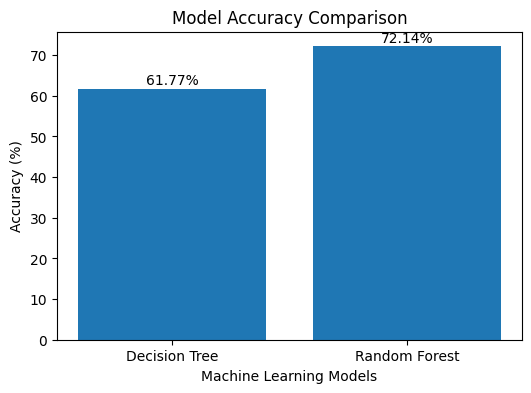

In [9]:
models = ["Decision Tree", "Random Forest"]
accuracy = [dt_acc * 100, rf_acc * 100]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(accuracy):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()